In [ ]:
!pip install matplotlib scipy

In [3]:
import json
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.stats import t

In [4]:
normal_experiment_constraints_file = 'zk_cred_logic/experiments/constraints.csv'
streaming_experiment_constraints_file = 'zk_cred_streaming_logic/experiments/constraints.csv'
normal_constraints_df = pd.read_csv(normal_experiment_constraints_file).reset_index(drop=True)
streaming_constraints_df = pd.read_csv(streaming_experiment_constraints_file).reset_index(drop=True)
constraints_df = pd.concat([normal_constraints_df, streaming_constraints_df, pd.DataFrame([{'k': 'cold_start', 'constraints': 1526683}])])

constraints_df['Constraints'] = constraints_df['constraints'].apply(lambda x: f"{x:,}")
constraints_df['History Size / Circuit Type'] = constraints_df['k'].apply(lambda x: 'Cold Start' if x == 'cold_start' else 'Streaming' if x == 'streaming' else f"{x:,}")

print(constraints_df[['History Size / Circuit Type', 'Constraints']].to_latex(index=False))

\begin{tabular}{ll}
\toprule
History Size / Circuit Type & Constraints \\
\midrule
1 & 30,317 \\
5 & 35,165 \\
10 & 35,995 \\
25 & 46,853 \\
50 & 67,739 \\
100 & 101,143 \\
250 & 209,723 \\
500 & 393,479 \\
1,000 & 752,623 \\
2,500 & 1,838,423 \\
5,000 & 3,650,879 \\
Streaming & 24,685 \\
Cold Start & 1,526,683 \\
\bottomrule
\end{tabular}



In [5]:
def load_results(path):
    with open(path, 'r') as f:
        data = json.load(f)
    data = [d for d in data if d.get('proveError') is None and d.get('verifyError') is None]
    prove = np.array([d['proveTimeMs'] for d in data])
    verify = np.array([d['verifyTimeMs'] for d in data])
    return prove, verify

def mean_ci(arr):
    n = len(arr)
    mean = np.mean(arr)
    stderr = np.std(arr, ddof=1) / np.sqrt(n)
    ci = t.ppf(0.975, n-1) * stderr
    return mean, ci

def get_k_from_filename(fname):
    return int(fname.split('_k')[-1].split('.')[0])

def aggregate_results(result_dir):
    files = sorted(glob(f"{result_dir}/experiment_results*k*.json"), key=get_k_from_filename)
    ks, means, cis, means_verify, cis_verify = [], [], [], [], []
    for f in files:
        k = get_k_from_filename(f)
        prove, verify = load_results(f)
        m, ci = mean_ci(prove)
        m_v, ci_v = mean_ci(verify)
        ks.append(k)
        means.append(m)
        cis.append(ci)
        means_verify.append(m_v)
        cis_verify.append(ci_v)
    return np.array(ks), np.array(means), np.array(cis), np.array(means_verify), np.array(cis_verify)

def load_streaming(result_dir):
    prove, verify = load_results(f"{result_dir}/experiment_results_streaming.json")
    m, ci = mean_ci(prove)
    m_v, ci_v = mean_ci(verify)
    return m, ci, m_v, ci_v

def load_cold_start(result_dir):
    prove, verify = load_results(f"{result_dir}/experiment_results_cold_start.json")
    m, ci = mean_ci(prove)
    m_v, ci_v = mean_ci(verify)
    return m, ci, m_v, ci_v

[<matplotlib.lines.Line2D object at 0x12084baf0>, <ErrorbarContainer object of 3 artists>, <ErrorbarContainer object of 3 artists>, <ErrorbarContainer object of 3 artists>]
['Streaming', 'Credential history', 'Chain attribution', 'Single attribution']


/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_6292/2831948430.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.93, 0.95])  # leave space for legend


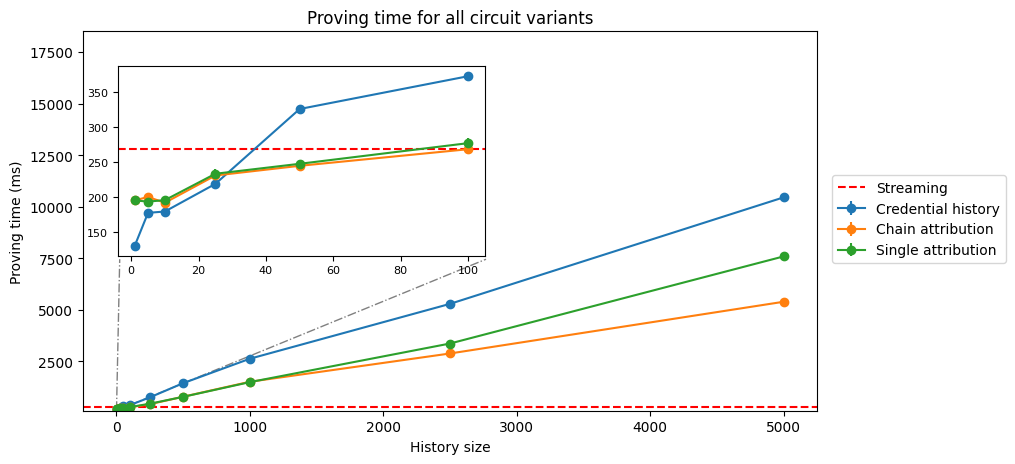

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# TODO: ATTRIBUTION CHAIN AND SINGLE

ks, means, cis, means_verify, cis_verify = aggregate_results("results")
ks_chain, means_chain, cis_chain, means_chain_verify, cis_chain_verify = aggregate_results("results_attribution_chain") 
ks_single, means_single, cis_single, means_single_verify, cis_single_verify = aggregate_results("results_attribution_single") 
# Streaming
m_stream_ldp, ci_stream_ldp, m_stream_verify, ci_stream_verify = load_streaming("results")

fig, ax_main = plt.subplots(1, 1, figsize=(9, 5))

# Main plot: all four time series
main_lines = []
main_lines += ax_main.errorbar(ks, means, yerr=cis, fmt='-o', label='Credential history').lines
main_lines += ax_main.errorbar(ks_chain, means_chain, yerr=cis_chain, fmt='-o', label='Chain attribution').lines
main_lines += ax_main.errorbar(ks_single, means_single, yerr=cis_single, fmt='-o', label='Single attribution').lines

ax_main.set_xlabel('History size')
ax_main.set_ylabel('Proving time (ms)')
ax_main.set_ylim(0, 18500)
ax_main.set_title('Proving time for all circuit variants')
# y_min = np.min(means - cis)
y_min = min(np.min(means - cis), np.min(means_chain - cis_chain), np.min(means_single - cis_single))
ax_main.set_ylim(bottom=y_min * 0.8)
ax_main.axhline(m_stream_ldp, color='red', linestyle='--', label='Streaming')

ax_main.yaxis.tick_left()
ax_main.tick_params(labelright=False)

# Inset: zoom in on small history sizes, top left
ax_inset = inset_axes(ax_main, width="50%", height="50%", loc='upper left', borderpad=2.5)
mask = (ks <= 100)
mask_chain = (ks_chain <= 100)
mask_single = (ks_single <= 100)
ax_inset.errorbar(ks[mask], means[mask], yerr=cis[mask], fmt='-o')
ax_inset.errorbar(ks_chain[mask_chain], means_chain[mask_chain], yerr=cis_chain[mask_chain], fmt='-o')
ax_inset.errorbar(ks_single[mask_single], means_single[mask_single], yerr=cis_single[mask_single], fmt='-o')
ax_inset.axhline(m_stream_ldp, color='red', linestyle='--', label='Streaming')
ax_inset.tick_params(axis='both', which='major', labelsize=8)

# Coordinates for the region in the main plot (in data coordinates)
x1, x2 = min(ks[mask]), max(ks[mask])
y1, y2 = min(means[mask]), max(means[mask])

# Lower left
xy_main1 = (x1, means[mask][0])
xy_inset1 = (x1, means[mask][0])
# Upper right
xy_main2 = (x2, means[mask][-1])
xy_inset2 = (x2, means[mask][-1])

ax_main.plot([x1, 25], [y1, 7450], color='gray', linestyle='-.', linewidth=1)
ax_main.plot([x2, 2770], [y2, 7450], color='gray', linestyle='-.', linewidth=1)

# Legend outside the main plot
handles, labels = ax_main.get_legend_handles_labels()
print(handles)
print(labels)

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.93, 0.5), borderaxespad=0., fontsize=10)

plt.tight_layout(rect=[0, 0, 0.93, 0.95])  # leave space for legend
plt.savefig("graphics/proving_v4.pdf", bbox_inches='tight')
plt.show()

In [50]:
means

array([  130.1772055 ,   177.8585634 ,   179.7581688 ,   219.26959671,
         326.17401256,   373.03383015,   748.30937859,  1438.51319013,
        2623.66969276,  5285.07291701, 10449.62452414])

In [8]:
means_chain

array([ 195.61755875,  200.50259918,  192.28045352,  231.22350932,
        245.04286731,  268.76561104,  417.51530179,  781.39353507,
       1507.48819955, 2878.70264611, 5386.67026704])

In [9]:
means_single

array([ 195.61755875,  193.93908541,  195.97983877,  233.68977419,
        247.90254878,  277.41029093,  441.84522425,  776.08824895,
       1489.3797785 , 3361.86192291, 7586.36224243])

In [11]:
m_stream_ldp, ci_stream_ldp

(np.float64(268.99863374999995), np.float64(10.253739144924067))

In [13]:
means_verify

array([15.13709752, 15.95058313, 15.76209004, 15.91302172, 16.96790849,
       17.03214826, 17.12103491, 19.37656921, 20.1853457 , 19.9943994 ,
       22.02217211])

In [14]:
means_chain_verify

array([18.28358532, 18.393674  , 17.91799753, 18.31334822, 18.0172756 ,
       18.319599  , 18.55865171, 19.87331798, 22.03729629, 22.26394932,
       21.93074629])

In [15]:
means_single_verify

array([18.28358532, 18.6253211 , 18.28577154, 19.3476001 , 18.21293046,
       19.28032899, 19.30272073, 19.18738423, 22.06028035, 24.04770921,
       26.54411365])

In [16]:
m_stream_verify

np.float64(29.807342170000002)

In [45]:
serverside_timing_df = pd.read_csv('results/serverside_timing_results.csv')

serverside_timing_df['verification_ms'] = serverside_timing_df['verification_ns'] / 1e6
serverside_timing_df['nullifier_ms'] = serverside_timing_df['nullifier_ns'] / 1e6
serverside_timing_df['signing_ms'] = serverside_timing_df['signing_ns'] / 1e6
serverside_timing_df['total_ms'] = serverside_timing_df['total_ns'] / 1e6
serverside_timing_df.drop(columns=['trial', 'verification_ns', 'nullifier_ns', 'signing_ns', 'total_ns'], inplace=True)
serverside_timing_df.describe()



,verification_ms,nullifier_ms,signing_ms,total_ms
count,200.000000,200.000000,200.000000,200.000000
mean,6.018575,0.007864,0.125177,6.268263
std,0.558385,0.002967,0.040817,0.846136
min,5.096709,0.005446,0.095026,5.249270
25%,5.776354,0.006823,0.111079,5.968018
50%,6.131209,0.007425,0.117725,6.338301
75%,6.261626,0.008113,0.125767,6.486012
max,10.320449,0.041772,0.578463,14.794500
